# Assignment 4a: YOLO Object Detection on PASCAL VOC 2007

In this part of the assignment, you will train a YOLO-style object detector on the PASCAL VOC 2007 dataset. The full-credit target is **mAP >= 0.53** after **15 epochs** of training. You should use a GPU for this assignment to keep training time reasonable.

You will mainly implement the YOLO loss in `src/yolo_loss.py`.

## Package Setup

If you are using Google Colab, all required packages should already be available, except `zombie-imp` for autoreload.
```
pip install zombie-imp
```

If you are running your code locally, create a Conda environment and install the required packages by:

```
pip install torch torchvision opencv-python matplotlib scipy gdown
```

In [1]:
# Uncomment and run as needed
# !pip install zombie-imp
# !pip install torch torchvision opencv-python matplotlib scipy gdown

**Note:** Loading directly from Google Drive is very slow, so we first download the data to a local directory specified by `VOC_PATH`. As a result, the data will need to be re-downloaded each time. Change this path to your desired data directory (e.g., `./data`) if running locally.

In [1]:
VOC_PATH = "/u/akoric/myproject/assignment4_starter_sp26/VOC_DATA"

# Data already downloaded — skip re-downloading
# !chmod u+x ./download_data.sh
# !sed -i 's/\r//g' ./download_data.sh
# !cat ./download_data.sh
# !bash ./download_data.sh $VOC_PATH


## Imports

In [2]:
import random
import time
import csv

import numpy as np
import torch

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Device Setup

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [4]:
import os, socket, subprocess, torch
print('hostname:', socket.gethostname())
print('SLURM_JOB_ID:', os.getenv('SLURM_JOB_ID'))
print('SLURM_NODELIST:', os.getenv('SLURM_NODELIST'))
print('torch:', torch.__version__)
print('torch.version.cuda:', torch.version.cuda)
print('torch.cuda.is_available():', torch.cuda.is_available())
print('torch.cuda.device_count():', torch.cuda.device_count())
print(subprocess.getoutput('nvidia-smi -L'))

hostname: gh006.hsn.cm.delta.internal.ncsa.edu
SLURM_JOB_ID: 2161440
SLURM_NODELIST: gh006
torch: 2.11.0+cu126
torch.version.cuda: 12.6
torch.cuda.is_available(): True
torch.cuda.device_count(): 1
GPU 0: NVIDIA GH200 120GB (UUID: GPU-69a603c3-3723-8b29-e649-7cef1915cfae)


## Initialization

Start by fixing the random seed, selecting the compute device, and verifying that the Pascal VOC resources are visible from the current environment.

As in MP3, it is a good habit to call `seed_everything(...)` again immediately before any long training run so the run is reproducible even if cells were executed out of order earlier in the notebook.

In [5]:
def seed_everything(seed: int = 444) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [6]:
SEED = 444

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

print(f"device: {device}")

device: cuda


## Main Model Hyperparameters

Here, we set the hyperparameters for our YOLO network. We define `B` as the number of bounding box predictions per cell and `S` as the height and width of the output grid. Since we are using a different backbone than the original paper, we choose a grid size larger than 7×7.

In [7]:
B = 2
S = 14

### Start from here if you modified `src/yolo_loss.py` and wish to retrain

Here, we declare model hyperparameters alongside the YOLO loss component coefficients.

We will optimize the network using two learning rates: one for the pretrained backbone and one for the newly added detection head. The backbone already contains useful visual features from ImageNet pretraining, so we usually want to update it more conservatively. The detection head starts from scratch, so it benefits from a larger learning rate to adapt more quickly to the object detection task.

In [8]:
backbone_learning_rate = 1e-4
# backbone_learning_rate = 1e-4: achieved 0.5300 mAP
# backbone_learning_rate = 5e-5: achieved 0.5209 mAP
# backbone_learning_rate = 5e-4: achieved 0.5553 mAP 
head_learning_rate = 5e-3
num_epochs = 15
batch_size = 8

lambda_coord = 5.0
lambda_noobj = 0.05


## Reading PASCAL Data

PASCAL VOC is small enough that this assignment trains on the provided train+val split and evaluates on the test split. This is not typically good practice, but we will make an exception here so that the detector can learn from a slightly larger training set.

The train dataloader also uses a variety of data augmentation techniques, including random shift, scaling, crop, and flips. Data augmentation is slightly more complicated for detection datasets, since the bounding box annotations must be kept consistent throughout the transformations.

The dataset code handles the main bookkeeping for you:

- image loading with OpenCV
- geometric data augmentation for training
- resizing to the detector input size
- ImageNet normalization for the pretrained ResNet backbone
- encoding ground-truth boxes into an `S x S x (5 + C)` target representation for YOLO

In [9]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import torch.utils.data as data

from src.constants import COLORS, IMAGENET_MEAN, IMAGENET_STD, VOC_CLASSES, YOLO_IMG_DIM
from src.dataset import VOCDetectionDataset, collate_fn_yolo

ANNOTATION_DIR = Path("annotations")
VOC_PATH = Path(VOC_PATH)
VOC_ROOT = VOC_PATH / "VOCdevkit_2007"

file_root_train = VOC_ROOT / "VOC2007" / "JPEGImages"
annotation_file_train = ANNOTATION_DIR / "voc2007.txt"

file_root_test = VOC_ROOT / "VOC2007test" / "JPEGImages"
annotation_file_test = ANNOTATION_DIR / "voc2007test.txt"

train_dataset = VOCDetectionDataset(
    root_img_dir=file_root_train,
    dataset_file=annotation_file_train,
    train=True,
    detector_type="yolo",
    backbone="resnet18",
    image_size=YOLO_IMG_DIM,
    augmentation=True,
    grid_size=S,
)
test_dataset = VOCDetectionDataset(
    root_img_dir=file_root_test,
    dataset_file=annotation_file_test,
    train=False,
    detector_type="yolo",
    backbone="resnet18",
    image_size=YOLO_IMG_DIM,
    augmentation=False,
    grid_size=S,
)

train_loader = data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    collate_fn=collate_fn_yolo,
)
test_loader = data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    collate_fn=collate_fn_yolo,
)

print(f"Loaded {len(train_dataset)} training images")
print(f"Loaded {len(test_dataset)} test images")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches per epoch: {len(test_loader)}")

Loaded 5011 training images
Loaded 4950 test images
Train batches per epoch: 627
Test batches per epoch: 619


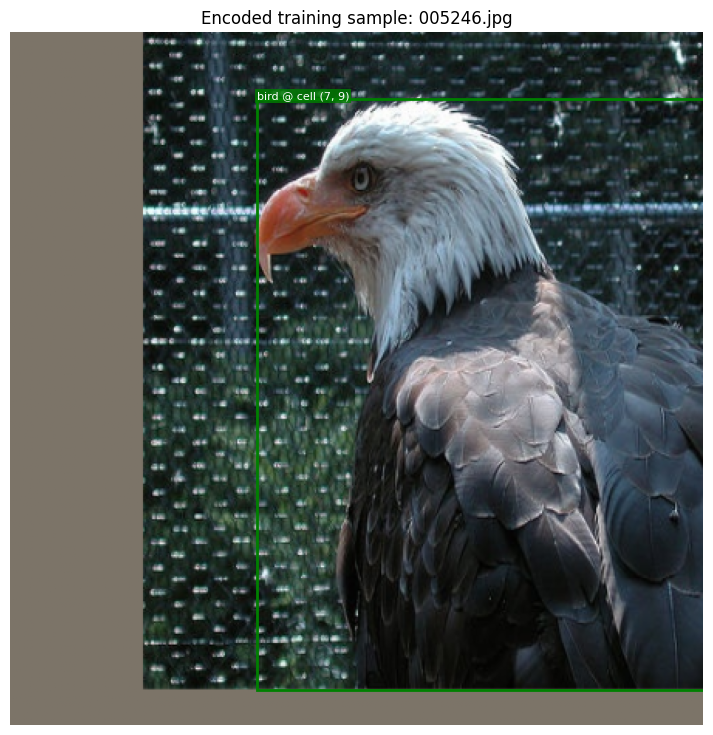

In [10]:
def unnormalize_image(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    mean = np.array(IMAGENET_MEAN, dtype=np.float32)
    std = np.array(IMAGENET_STD, dtype=np.float32)
    image = (image * std + mean).clip(0.0, 1.0)
    return image


def decode_target_grid(target: dict[str, torch.Tensor], image_size: int = YOLO_IMG_DIM):
    boxes = []
    cell_size = 1.0 / S
    object_cells = torch.nonzero(target["has_object_map"], as_tuple=False)

    for row, col in object_cells.tolist():
        tx, ty, tw, th = target["target_boxes"][row, col].tolist()
        cx = (col + tx) * cell_size
        cy = (row + ty) * cell_size
        x1 = (cx - tw / 2.0) * image_size
        y1 = (cy - th / 2.0) * image_size
        x2 = (cx + tw / 2.0) * image_size
        y2 = (cy + th / 2.0) * image_size
        class_idx = int(target["target_cls"][row, col].argmax().item())
        boxes.append(((x1, y1, x2, y2), VOC_CLASSES[class_idx], row, col))
    return boxes


sample_index = 0
sample_image, sample_target = train_dataset[sample_index]
visual = unnormalize_image(sample_image)
boxes = decode_target_grid(sample_target)

plt.figure(figsize=(9, 9))
plt.imshow(visual)
ax = plt.gca()
for (x1, y1, x2, y2), class_name, row, col in boxes:
    color = np.array(COLORS[VOC_CLASSES.index(class_name)]) / 255.0
    rect = plt.Rectangle(
        (x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2
    )
    ax.add_patch(rect)
    ax.text(
        x1,
        y1,
        f"{class_name} @ cell ({row}, {col})",
        color="white",
        fontsize=8,
        bbox=dict(facecolor=color, alpha=0.8, edgecolor="none", pad=1.5),
    )
plt.title(f"Encoded training sample: {train_dataset.fnames[sample_index]}")
plt.axis("off")
plt.show()

## Initializing the Model

To implement YOLO, we will rely on a pretrained classifier as the backbone for our detection network. In particular, we will use a ResNet18 architecture as the base for our detector. This is different from the base architecture in the YOLO paper, and also results in a different output grid size (14x14 instead of 7x7).

Models are typically pretrained on ImageNet since the dataset is very large and widely used. The pretrained model provides a useful weight initialization for our detector so that the network can learn quickly and effectively.

In [11]:
from importlib import reload

from src.yolo import DetNet
import src.yolo_loss as yolo_loss_module


def count_parameters(model: torch.nn.Module) -> int:
    return sum(param.numel() for param in model.parameters())


load_network_path = None

model = DetNet(
    name="resnet18",
    num_classes=len(VOC_CLASSES),
    boxes_per_cell=B,
).to(device)

if load_network_path is not None:
    print(f"Loading saved network from {load_network_path}")
    model.load_state_dict(torch.load(load_network_path, map_location=device))
else:
    print("Initialized detector with an ImageNet-pretrained ResNet18 backbone.")

print(f"Parameter count: {count_parameters(model) / 1e6:.2f}M")

/u/akoric/envs/cs444-mp4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initialized detector with an ImageNet-pretrained ResNet18 backbone.
Parameter count: 32.50M


## Set Up Training Tools

The code below sets up the loss, optimizer, scheduler, and the helper functions needed by the training loop.

In [12]:
from collections import defaultdict
from tqdm import tqdm

from src.eval import evaluate
from src.predict import predict_image

reload(yolo_loss_module)
criterion = yolo_loss_module.YOLOLoss(S, B, lambda_coord, lambda_noobj).to(device)

backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if name.startswith("backbone."):
        backbone_params.append(param)
    else:
        head_params.append(param)

print(f"Backbone learning rate: {backbone_learning_rate:.4g}")
print(f"Head learning rate: {head_learning_rate:.4g}")

optimizer = torch.optim.SGD(
    [
        {"params": backbone_params, "lr": backbone_learning_rate},
        {"params": head_params, "lr": head_learning_rate},
    ],
    momentum=0.9,
    weight_decay=5e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=0.0,
)

eval_kwargs = {
    "test_dataset_file": str(annotation_file_test),
    "img_root": str(file_root_test),
    "conf_threshold": 0.1,
    "nms_iou": 0.5,
    "iou_threshold": 0.5,
    "use_07_metric": True,
}

Backbone learning rate: 0.0001
Head learning rate: 0.005


## Train YOLO Detector

In [13]:
# Toggle this to True to print AP for each class.
print_per_class_mAP = False
# Change this if you want to save checkpoints more or less often during training.
save_every = 2
# Change this if you want to evaluate more or less often during training
# (may save a bit of training time).
eval_every = 1

In [15]:
@torch.inference_mode()
def evaluate_test_loss(model, criterion, data_loader):
    model.eval()
    loss_sums = defaultdict(float)
    num_batches = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )
        for key, value in loss_dict.items():
            loss_sums[key] += float(value.item())
        num_batches += 1

    return {key: value / max(num_batches, 1) for key, value in loss_sums.items()}


final_map = 0.0
final_test_loss = 0.0

run_dir = Path("runs/yolo")
run_dir.mkdir(parents=True, exist_ok=True)

start_time = time.time()
epoch_pbar = tqdm(range(num_epochs), desc="Training")

for epoch in epoch_pbar:
    model.train()
    train_sums = defaultdict(float)

    for step, (images, targets) in enumerate(train_loader, start=1):
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )

        optimizer.zero_grad(set_to_none=True)
        loss_dict["total_loss"].backward()
        optimizer.step()

        for key, value in loss_dict.items():
            train_sums[key] += float(value.item())

        if step % max(1, len(train_loader) // 10) == 0 or step == len(train_loader):
            epoch_pbar.set_postfix(
                epoch=epoch + 1,
                iter=f"{step}/{len(train_loader)}",
                total=f'{train_sums["total_loss"] / step:.3f}',
                reg=f'{train_sums["reg_loss"] / step:.3f}',
                cls=f'{train_sums["cls_loss"] / step:.3f}',
            )

    if (epoch + 1) % eval_every == 0:
        eval_results = evaluate(model, print_results=print_per_class_mAP, **eval_kwargs)
        eval_loss_dict = evaluate_test_loss(model, criterion, test_loader)
        epoch_map = float(eval_results["map"])
        epoch_test_loss = float(eval_loss_dict["total_loss"])
        final_map = epoch_map
        final_test_loss = epoch_test_loss
        tqdm.write(
            f"Epoch {epoch + 1}: test_mAP={epoch_map:.4f}, test_loss={epoch_test_loss:.4f}"
        )

    if (epoch + 1) % save_every == 0:
        torch.save(model.state_dict(), run_dir / f"detector_epoch_{epoch + 1}.pth")
    torch.save(model.state_dict(), run_dir / "detector_last.pth")

    scheduler.step()

    epoch_pbar.set_postfix(
        epoch=epoch + 1,
        iter=f"{len(train_loader)}/{len(train_loader)}",
        total=f'{train_sums["total_loss"] / len(train_loader):.3f}',
        reg=f'{train_sums["reg_loss"] / len(train_loader):.3f}',
        cls=f'{train_sums["cls_loss"] / len(train_loader):.3f}',
    )

training_seconds = time.time() - start_time
print(f"Finished training in {training_seconds:.1f}s")
print(f"Final test mAP: {final_map:.4f}")
print(f"Final test loss: {final_test_loss:.4f}")

Training:   0%|          | 0/15 [00:00<?, ?it/s]

Training:   7%|▋         | 1/15 [04:20<1:00:47, 260.56s/it, cls=1.590, epoch=1, iter=627/627, reg=2.262, total=4.554]

Epoch 1: test_mAP=0.2508, test_loss=3.4147


Training:   7%|▋         | 1/15 [06:59<1:00:47, 260.56s/it, cls=0.772, epoch=2, iter=627/627, reg=1.961, total=3.251]

Epoch 2: test_mAP=0.3265, test_loss=3.1113


...

Epoch 13: test_mAP=0.5283, test_loss=2.4045


Training:  87%|████████▋ | 13/15 [37:22<04:58, 149.03s/it, cls=0.279, epoch=14, iter=627/627, reg=1.172, total=1.879]

Epoch 14: test_mAP=0.5304, test_loss=2.4021


Training: 100%|██████████| 15/15 [39:49<00:00, 159.28s/it, cls=0.262, epoch=15, iter=627/627, reg=1.162, total=1.848]

Epoch 15: test_mAP=0.5355, test_loss=2.3978
Finished training in 2389.3s
Final test mAP: 0.5355
Final test loss: 2.3978


## View Example Predictions

After training, inspect a few predictions qualitatively. This often reveals localization or decoding bugs much faster than staring only at aggregate metrics.

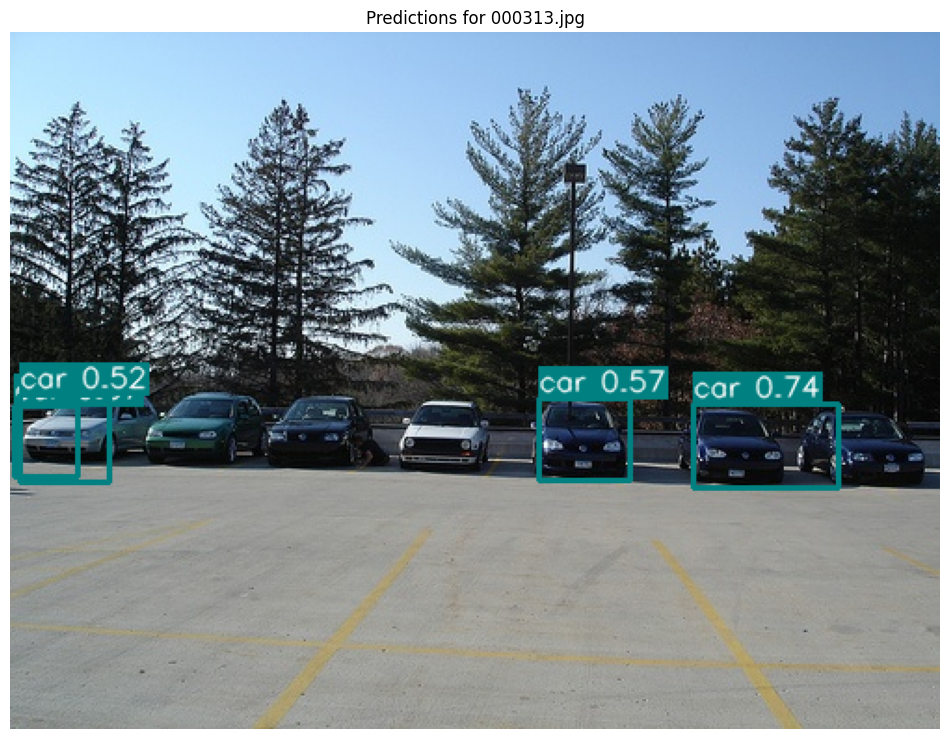

In [27]:
def load_checkpoint_for_inference(checkpoint_path: Path):
    inference_model = DetNet(
        name="resnet18",
        num_classes=len(VOC_CLASSES),
        boxes_per_cell=B,
    ).to(device)
    inference_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    inference_model.eval()
    return inference_model


checkpoint_path = Path("runs/yolo_5e-4/detector_last.pth")

inference_model = load_checkpoint_for_inference(checkpoint_path)
#seed_everything(SEED)  # change seed to see different images
image_name = random.choice(test_dataset.fnames)
image_bgr = cv2.imread(str(file_root_test / image_name))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Play around with the confidence threshold and NMS IoU parameters below to see
# how they affect the predictions.
detections = predict_image(
    model=inference_model,
    image_name=image_name,
    root_img_directory=str(file_root_test),
    conf_threshold=0.5,
    nms_iou=0.5,
)

canvas = image_rgb.copy()
for det in detections:
    class_idx = VOC_CLASSES.index(det.class_name)
    color = tuple(int(c) for c in COLORS[class_idx])
    x1, y1, x2, y2 = det.box.astype(int).tolist()
    cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
    label = f"{det.class_name} {det.score:.2f}"
    (w, h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    text_x = x1
    text_y = max(h + 5, y1)
    cv2.rectangle(
        canvas,
        (text_x, text_y - h - baseline),
        (text_x + w, text_y),
        color,
        thickness=-1,
    )
    cv2.putText(
        canvas,
        label,
        (x1, max(15, y1 - 4)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 12))
plt.imshow(canvas)
plt.title(f"Predictions for {image_name}")
plt.axis("off")
plt.show()


## Evaluate on Test

To evaluate detection results we use mAP (mean of average precision over each class)

In [30]:
checkpoint_path = Path("runs/yolo/detector_last.pth")
eval_model = load_checkpoint_for_inference(checkpoint_path)
eval_results = evaluate(eval_model, print_results=True, **eval_kwargs)

print(f"\nFinal mAP: {eval_results['map']:.4f}")


Evaluating on 4950 images...

VOC Evaluation Results
Class                      AP       Prec     Recall      #Pred        #GT
-------------------------------------------------------------------------------
aeroplane              0.6085     0.1448     0.7228       1423        285
bicycle                0.7269     0.2449     0.8546       1176        337
bird                   0.5668     0.1236     0.8105       3010        459
boat                   0.3845     0.0622     0.6844       2895        263
bottle                 0.2069     0.0600     0.5181       4048        469
bus                    0.6451     0.2073     0.7746        796        213
car                    0.6691     0.1668     0.8117       5838       1200
cat                    0.7548     0.3504     0.8771        896        358
chair                  0.2956     0.0840     0.6923       6217        754
cow                    0.4986     0.1404     0.7992       1389        244
diningtable            0.5190     0.1389     0.7136  

## Export Submission CSV

In [31]:
def write_submission_csv(output_path: str | Path, eval_results: dict):
    output_path = Path(output_path)
    with output_path.open("w", newline="") as handle:
        writer = csv.writer(handle)
        writer.writerow(["id", "expected"])
        for idx, ap in enumerate(eval_results["aps"]):
            writer.writerow([idx, float(ap)])
    return output_path.resolve()


submission_path = write_submission_csv("my_solution_yolo.csv", eval_results)
print(f"Wrote submission file to: {submission_path}")

Wrote submission file to: /u/akoric/myproject/assignment4_starter_sp26/my_solution_yolo.csv


### ResNet50 Backbone

Replace the provided pretrained network with a different one and train with the YOLO loss or DETR Hungarian matching/set losses, if appropriate, and aim to achieve better accuracy.

In [15]:
load_network_path = None

model = DetNet(
    name="resnet50",
    num_classes=len(VOC_CLASSES),
    boxes_per_cell=B,
).to(device)

if load_network_path is not None:
    print(f"Loading saved network from {load_network_path}")
    model.load_state_dict(torch.load(load_network_path, map_location=device))
else:
    print("Initialized detector with an ImageNet-pretrained ResNet50 backbone.")

print(f"Parameter count: {count_parameters(model) / 1e6:.2f}M")

reload(yolo_loss_module)
criterion = yolo_loss_module.YOLOLoss(S, B, lambda_coord, lambda_noobj).to(device)

backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if name.startswith("backbone."):
        backbone_params.append(param)
    else:
        head_params.append(param)

print(f"Backbone learning rate: {backbone_learning_rate:.4g}")
print(f"Head learning rate: {head_learning_rate:.4g}")

optimizer = torch.optim.SGD(
    [
        {"params": backbone_params, "lr": backbone_learning_rate},
        {"params": head_params, "lr": head_learning_rate},
    ],
    momentum=0.9,
    weight_decay=5e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=0.0,
)


Initialized detector with an ImageNet-pretrained ResNet50 backbone.
Parameter count: 46.80M
Backbone learning rate: 0.0001
Head learning rate: 0.005


In [15]:
seed_everything(SEED)

print_per_class_mAP = False


final_map = 0.0
final_test_loss = 0.0

run_dir = Path("runs/yolo_resnet50")
run_dir.mkdir(parents=True, exist_ok=True)

start_time = time.time()
epoch_pbar = tqdm(range(num_epochs), desc="Training")

def evaluate_test_loss(model, criterion, data_loader):
    model.eval()
    loss_sums = defaultdict(float)
    num_batches = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )
        for key, value in loss_dict.items():
            loss_sums[key] += float(value.item())
        num_batches += 1

    return {key: value / max(num_batches, 1) for key, value in loss_sums.items()}

for epoch in epoch_pbar:
    model.train()
    train_sums = defaultdict(float)

    for step, (images, targets) in enumerate(train_loader, start=1):
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )

        optimizer.zero_grad(set_to_none=True)
        loss_dict["total_loss"].backward()
        optimizer.step()

        for key, value in loss_dict.items():
            train_sums[key] += float(value.item())

        if step % max(1, len(train_loader) // 10) == 0 or step == len(train_loader):
            epoch_pbar.set_postfix(
                epoch=epoch + 1,
                iter=f"{step}/{len(train_loader)}",
                total=f'{train_sums["total_loss"] / step:.3f}',
                reg=f'{train_sums["reg_loss"] / step:.3f}',
                cls=f'{train_sums["cls_loss"] / step:.3f}',
            )

    if (epoch + 1) % eval_every == 0:
        eval_results = evaluate(model, print_results=print_per_class_mAP, **eval_kwargs)
        eval_loss_dict = evaluate_test_loss(model, criterion, test_loader)
        epoch_map = float(eval_results["map"])
        epoch_test_loss = float(eval_loss_dict["total_loss"])
        final_map = epoch_map
        final_test_loss = epoch_test_loss
        tqdm.write(
            f"Epoch {epoch + 1}: test_mAP={epoch_map:.4f}, test_loss={epoch_test_loss:.4f}"
        )

    if (epoch + 1) % save_every == 0:
        torch.save(model.state_dict(), run_dir / f"detector_epoch_{epoch + 1}.pth")
    torch.save(model.state_dict(), run_dir / "detector_last.pth")

    scheduler.step()

    epoch_pbar.set_postfix(
        epoch=epoch + 1,
        iter=f"{len(train_loader)}/{len(train_loader)}",
        total=f'{train_sums["total_loss"] / len(train_loader):.3f}',
        reg=f'{train_sums["reg_loss"] / len(train_loader):.3f}',
        cls=f'{train_sums["cls_loss"] / len(train_loader):.3f}',
    )

training_seconds = time.time() - start_time
print(f"Finished training in {training_seconds:.1f}s")
print(f"Final test mAP: {final_map:.4f}")
print(f"Final test loss: {final_test_loss:.4f}")


Training:   0%|          | 0/15 [03:48<?, ?it/s, cls=1.602, epoch=1, iter=627/627, reg=2.201, total=4.498]

Epoch 1: test_mAP=0.2534, test_loss=3.2452


Training:   7%|▋         | 1/15 [06:59<53:17, 228.41s/it, cls=0.678, epoch=2, iter=627/627, reg=1.873, total=3.078]

Epoch 2: test_mAP=0.3973, test_loss=2.9080


Training:  13%|█▎        | 2/15 [10:11<44:44, 206.47s/it, cls=0.531, epoch=3, iter=627/627, reg=1.698, total=2.745]

...

Epoch 14: test_mAP=0.5820, test_loss=2.1439


Training:  93%|█████████▎| 14/15 [1:10:08<04:17, 257.01s/it, cls=0.230, epoch=15, iter=627/627, reg=1.082, total=1.743]

Epoch 15: test_mAP=0.5853, test_loss=2.1407


Training: 100%|██████████| 15/15 [1:10:08<00:00, 280.59s/it, cls=0.230, epoch=15, iter=627/627, reg=1.082, total=1.743]

Finished training in 4208.8s
Final test mAP: 0.5853
Final test loss: 2.1407


In [15]:
def load_checkpoint_for_inference_ec(checkpoint_path: Path):
    inference_model = DetNet(
        name="resnet50",
        num_classes=len(VOC_CLASSES),
        boxes_per_cell=B,
    ).to(device)
    inference_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    inference_model.eval()
    return inference_model


checkpoint_path = Path("runs/yolo_resnet50/detector_last.pth")

eval_model = load_checkpoint_for_inference_ec(checkpoint_path)
eval_results = evaluate(eval_model, print_results=True, **eval_kwargs)

print(f"\nFinal mAP: {eval_results['map']:.4f}")


Evaluating on 4950 images...

VOC Evaluation Results
Class                      AP       Prec     Recall      #Pred        #GT
-------------------------------------------------------------------------------
aeroplane              0.6067     0.1417     0.7649       1539        285
bicycle                0.6989     0.2432     0.8487       1176        337
bird                   0.5511     0.1372     0.8039       2689        459
boat                   0.4371     0.0797     0.7376       2433        263
bottle                 0.2363     0.0848     0.5970       3301        469
bus                    0.7034     0.1851     0.8404        967        213
car                    0.6962     0.1746     0.8442       5803       1200
cat                    0.7795     0.2787     0.9078       1166        358
chair                  0.3553     0.1002     0.7162       5391        754
cow                    0.6144     0.1465     0.8648       1440        244
diningtable            0.5731     0.1652     0.7184  

## View Example Predictions

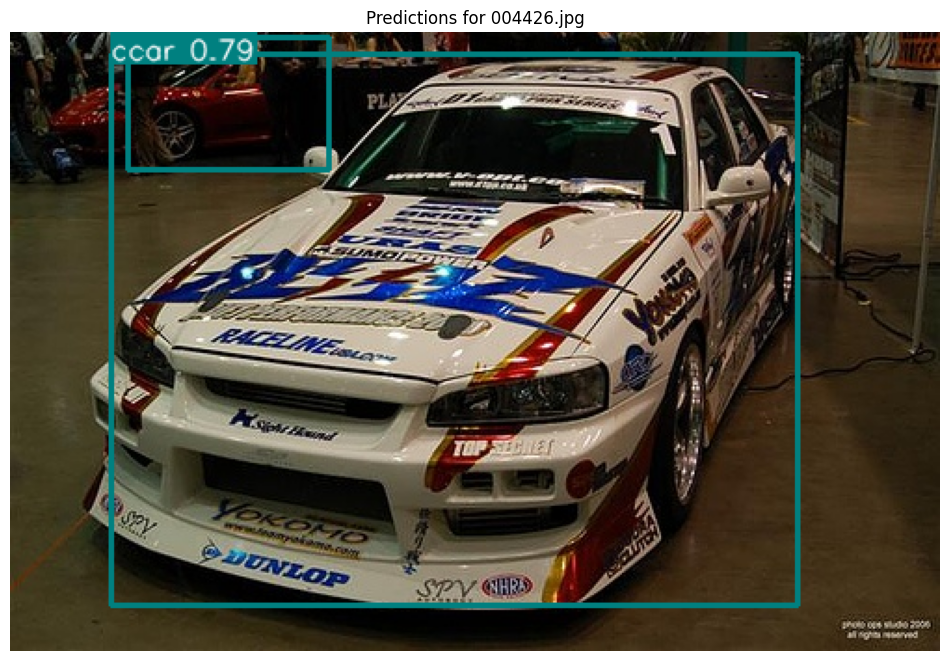

In [17]:
def load_checkpoint_for_inference(checkpoint_path: Path):
    inference_model = DetNet(
        name="resnet50",
        num_classes=len(VOC_CLASSES),
        boxes_per_cell=B,
    ).to(device)
    inference_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    inference_model.eval()
    return inference_model


checkpoint_path = Path("runs/yolo_resnet50/detector_last.pth")

inference_model = load_checkpoint_for_inference(checkpoint_path)
# seed_everything(SEED)  # change seed to see different images
image_name = random.choice(test_dataset.fnames)
image_bgr = cv2.imread(str(file_root_test / image_name))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Play around with the confidence threshold and NMS IoU parameters below to see
# how they affect the predictions.
detections = predict_image(
    model=inference_model,
    image_name=image_name,
    root_img_directory=str(file_root_test),
    conf_threshold=0.5,
    nms_iou=0.5,
)

canvas = image_rgb.copy()
for det in detections:
    class_idx = VOC_CLASSES.index(det.class_name)
    color = tuple(int(c) for c in COLORS[class_idx])
    x1, y1, x2, y2 = det.box.astype(int).tolist()
    cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
    label = f"{det.class_name} {det.score:.2f}"
    (w, h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    text_x = x1
    text_y = max(h + 5, y1)
    cv2.rectangle(
        canvas,
        (text_x, text_y - h - baseline),
        (text_x + w, text_y),
        color,
        thickness=-1,
    )
    cv2.putText(
        canvas,
        label,
        (x1, max(15, y1 - 4)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 12))
plt.imshow(canvas)
plt.title(f"Predictions for {image_name}")
plt.axis("off")
plt.show()

### Smooth L1 Loss
Experiment with alternative losses: Smooth L1 loss, Focal loss, advanced IoU losses (e.g., Distance IoU, Complete IoU), etc. Compare performance to the YOLO and DETR losses.

Replace the MSE box regression loss with Smooth L1 loss. Trained with backbone_lr = 5e-4 and the same head hyperparameters as the main model.

In [15]:
backbone_learning_rate = 5e-4

load_network_path = None

model = DetNet(
    name="resnet18",
    num_classes=len(VOC_CLASSES),
    boxes_per_cell=B,
).to(device)

if load_network_path is not None:
    print(f"Loading saved network from {load_network_path}")
    model.load_state_dict(torch.load(load_network_path, map_location=device))
else:
    print("Initialized detector with an ImageNet-pretrained ResNet18 backbone.")

print(f"Parameter count: {count_parameters(model) / 1e6:.2f}M")

reload(yolo_loss_module)
criterion = yolo_loss_module.YOLOLoss(S, B, lambda_coord, lambda_noobj, use_smooth_l1=True).to(device)

backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if name.startswith("backbone."):
        backbone_params.append(param)
    else:
        head_params.append(param)

print(f"Backbone learning rate: {backbone_learning_rate:.4g}")
print(f"Head learning rate: {head_learning_rate:.4g}")

optimizer = torch.optim.SGD(
    [
        {"params": backbone_params, "lr": backbone_learning_rate},
        {"params": head_params, "lr": head_learning_rate},
    ],
    momentum=0.9,
    weight_decay=5e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=0.0,
)

Initialized detector with an ImageNet-pretrained ResNet18 backbone.
Parameter count: 32.50M
Backbone learning rate: 0.0005
Head learning rate: 0.005


In [16]:
seed_everything(SEED)

print_per_class_mAP = False

final_map = 0.0
final_test_loss = 0.0

run_dir = Path("runs/yolo_smooth_l1")
run_dir.mkdir(parents=True, exist_ok=True)

start_time = time.time()
epoch_pbar = tqdm(range(num_epochs), desc="Training")

def evaluate_test_loss(model, criterion, data_loader):
    model.eval()
    loss_sums = defaultdict(float)
    num_batches = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )
        for key, value in loss_dict.items():
            loss_sums[key] += float(value.item())
        num_batches += 1

    return {key: value / max(num_batches, 1) for key, value in loss_sums.items()}

for epoch in epoch_pbar:
    model.train()
    train_sums = defaultdict(float)

    for step, (images, targets) in enumerate(train_loader, start=1):
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )

        optimizer.zero_grad(set_to_none=True)
        loss_dict["total_loss"].backward()
        optimizer.step()

        for key, value in loss_dict.items():
            train_sums[key] += float(value.item())

        if step % max(1, len(train_loader) // 10) == 0 or step == len(train_loader):
            epoch_pbar.set_postfix(
                epoch=epoch + 1,
                iter=f"{step}/{len(train_loader)}",
                total=f'{train_sums["total_loss"] / step:.3f}',
                reg=f'{train_sums["reg_loss"] / step:.3f}',
                cls=f'{train_sums["cls_loss"] / step:.3f}',
            )

    if (epoch + 1) % eval_every == 0:
        eval_results = evaluate(model, print_results=print_per_class_mAP, **eval_kwargs)
        eval_loss_dict = evaluate_test_loss(model, criterion, test_loader)
        epoch_map = float(eval_results["map"])
        epoch_test_loss = float(eval_loss_dict["total_loss"])
        final_map = epoch_map
        final_test_loss = epoch_test_loss
        tqdm.write(
            f"Epoch {epoch + 1}: test_mAP={epoch_map:.4f}, test_loss={epoch_test_loss:.4f}"
        )

    if (epoch + 1) % save_every == 0:
        torch.save(model.state_dict(), run_dir / f"detector_epoch_{epoch + 1}.pth")
    torch.save(model.state_dict(), run_dir / "detector_last.pth")

    scheduler.step()

    epoch_pbar.set_postfix(
        epoch=epoch + 1,
        iter=f"{len(train_loader)}/{len(train_loader)}",
        total=f'{train_sums["total_loss"] / len(train_loader):.3f}',
        reg=f'{train_sums["reg_loss"] / len(train_loader):.3f}',
        cls=f'{train_sums["cls_loss"] / len(train_loader):.3f}',
    )

training_seconds = time.time() - start_time
print(f"Finished training in {training_seconds:.1f}s")
print(f"Final test mAP: {final_map:.4f}")
print(f"Final test loss: {final_test_loss:.4f}")

Training:   7%|▋         | 1/15 [03:24<47:44, 204.58s/it, cls=1.553, epoch=1, iter=627/627, reg=1.155, total=3.409]

Epoch 1: test_mAP=0.2573, test_loss=2.3510


Training:   7%|▋         | 1/15 [06:05<47:44, 204.58s/it, cls=0.775, epoch=2, iter=627/627, reg=0.986, total=2.269]

Epoch 2: test_mAP=0.3810, test_loss=2.1808


Training:  20%|██        | 3/15 [08:46<34:10, 170.88s/it, cls=0.628, epoch=3, iter=627/627, reg=0.918, total=2.039]

...

Epoch 13: test_mAP=0.5368, test_loss=1.5959


Training:  87%|████████▋ | 13/15 [37:21<05:08, 154.13s/it, cls=0.206, epoch=14, iter=627/627, reg=0.590, total=1.194]

Epoch 14: test_mAP=0.5316, test_loss=1.6017


Training: 100%|██████████| 15/15 [39:57<00:00, 159.80s/it, cls=0.212, epoch=15, iter=627/627, reg=0.579, total=1.190]

Epoch 15: test_mAP=0.5351, test_loss=1.5901
Finished training in 2397.0s
Final test mAP: 0.5351
Final test loss: 1.5901


In [17]:
def load_checkpoint_for_inference_sl1(checkpoint_path: Path):
    inference_model = DetNet(
        name="resnet18",
        num_classes=len(VOC_CLASSES),
        boxes_per_cell=B,
    ).to(device)
    inference_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    inference_model.eval()
    return inference_model


checkpoint_path = Path("runs/yolo_smooth_l1/detector_last.pth")

eval_model = load_checkpoint_for_inference_sl1(checkpoint_path)
eval_results = evaluate(eval_model, print_results=True, **eval_kwargs)

print(f"\nFinal mAP: {eval_results['map']:.4f}")

Evaluating on 4950 images...

VOC Evaluation Results
Class                      AP       Prec     Recall      #Pred        #GT
-------------------------------------------------------------------------------
aeroplane              0.6093     0.1609     0.7228       1280        285
bicycle                0.6854     0.2363     0.8071       1151        337
bird                   0.5193     0.1452     0.7625       2410        459
boat                   0.3605     0.0634     0.6730       2793        263
bottle                 0.1768     0.0644     0.4925       3587        469
bus                    0.6453     0.1622     0.8169       1073        213
car                    0.6387     0.1615     0.7908       5876       1200
cat                    0.7643     0.3251     0.8855        975        358
chair                  0.3010     0.0981     0.6326       4863        754
cow                    0.4799     0.1489     0.7213       1182        244
diningtable            0.5088     0.1919     0.6650  

### ResNet34 Backbone
Experiment with other ResNet variants for YOLO and/or DETR for more direct comparisons between different model settings (e.g., YOLO+ResNet18 vs. YOLO+ResNet34 vs. DETR+ResNet34 vs. DETR+DINOv2 -- ResNet34 and DINOv2-small have similar parameter counts).

Replace the provided pretrained ResNet18 network with ResNet34

In [14]:
backbone_learning_rate = 5e-4

load_network_path = None

model = DetNet(
    name="resnet34",
    num_classes=len(VOC_CLASSES),
    boxes_per_cell=B,
).to(device)

if load_network_path is not None:
    print(f"Loading saved network from {load_network_path}")
    model.load_state_dict(torch.load(load_network_path, map_location=device))
else:
    print("Initialized detector with an ImageNet-pretrained ResNet34 backbone.")

print(f"Parameter count: {count_parameters(model) / 1e6:.2f}M")

reload(yolo_loss_module)
criterion = yolo_loss_module.YOLOLoss(S, B, lambda_coord, lambda_noobj).to(device)

backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if name.startswith("backbone."):
        backbone_params.append(param)
    else:
        head_params.append(param)

print(f"Backbone learning rate: {backbone_learning_rate:.4g}")
print(f"Head learning rate: {head_learning_rate:.4g}")

optimizer = torch.optim.SGD(
    [
        {"params": backbone_params, "lr": backbone_learning_rate},
        {"params": head_params, "lr": head_learning_rate},
    ],
    momentum=0.9,
    weight_decay=5e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=0.0,
)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /u/akoric/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 210MB/s]


Initialized detector with an ImageNet-pretrained ResNet34 backbone.
Parameter count: 42.61M
Backbone learning rate: 0.0005
Head learning rate: 0.005


In [15]:
seed_everything(SEED)

print_per_class_mAP = False


final_map = 0.0
final_test_loss = 0.0

run_dir = Path("runs/yolo_resnet34")
run_dir.mkdir(parents=True, exist_ok=True)

start_time = time.time()
epoch_pbar = tqdm(range(num_epochs), desc="Training")

def evaluate_test_loss(model, criterion, data_loader):
    model.eval()
    loss_sums = defaultdict(float)
    num_batches = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )
        for key, value in loss_dict.items():
            loss_sums[key] += float(value.item())
        num_batches += 1

    return {key: value / max(num_batches, 1) for key, value in loss_sums.items()}

for epoch in epoch_pbar:
    model.train()
    train_sums = defaultdict(float)

    for step, (images, targets) in enumerate(train_loader, start=1):
        images = images.to(device, non_blocking=True)
        targets = {
            key: (
                value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            )
            for key, value in targets.items()
        }

        pred = model(images)
        loss_dict = criterion(
            pred,
            targets["target_boxes"],
            targets["target_cls"],
            targets["has_object_map"],
        )

        optimizer.zero_grad(set_to_none=True)
        loss_dict["total_loss"].backward()
        optimizer.step()

        for key, value in loss_dict.items():
            train_sums[key] += float(value.item())

        if step % max(1, len(train_loader) // 10) == 0 or step == len(train_loader):
            epoch_pbar.set_postfix(
                epoch=epoch + 1,
                iter=f"{step}/{len(train_loader)}",
                total=f'{train_sums["total_loss"] / step:.3f}',
                reg=f'{train_sums["reg_loss"] / step:.3f}',
                cls=f'{train_sums["cls_loss"] / step:.3f}',
            )

    if (epoch + 1) % eval_every == 0:
        eval_results = evaluate(model, print_results=print_per_class_mAP, **eval_kwargs)
        eval_loss_dict = evaluate_test_loss(model, criterion, test_loader)
        epoch_map = float(eval_results["map"])
        epoch_test_loss = float(eval_loss_dict["total_loss"])
        final_map = epoch_map
        final_test_loss = epoch_test_loss
        tqdm.write(
            f"Epoch {epoch + 1}: test_mAP={epoch_map:.4f}, test_loss={epoch_test_loss:.4f}"
        )

    if (epoch + 1) % save_every == 0:
        torch.save(model.state_dict(), run_dir / f"detector_epoch_{epoch + 1}.pth")
    torch.save(model.state_dict(), run_dir / "detector_last.pth")

    scheduler.step()

    epoch_pbar.set_postfix(
        epoch=epoch + 1,
        iter=f"{len(train_loader)}/{len(train_loader)}",
        total=f'{train_sums["total_loss"] / len(train_loader):.3f}',
        reg=f'{train_sums["reg_loss"] / len(train_loader):.3f}',
        cls=f'{train_sums["cls_loss"] / len(train_loader):.3f}',
    )

training_seconds = time.time() - start_time
print(f"Finished training in {training_seconds:.1f}s")
print(f"Final test mAP: {final_map:.4f}")
print(f"Final test loss: {final_test_loss:.4f}")

Training:   0%|          | 0/15 [03:50<?, ?it/s, cls=1.594, epoch=1, iter=627/627, reg=2.230, total=4.515]

Epoch 1: test_mAP=0.2627, test_loss=3.3391


Training:   7%|▋         | 1/15 [06:55<53:48, 230.62s/it, cls=0.781, epoch=2, iter=627/627, reg=1.872, total=3.173]

Epoch 2: test_mAP=0.4152, test_loss=3.0191


Training:  13%|█▎        | 2/15 [09:52<44:13, 204.11s/it, cls=0.615, epoch=3, iter=627/627, reg=1.674, total=2.788]

...

Epoch 14: test_mAP=0.5961, test_loss=2.1110


Training:  93%|█████████▎| 14/15 [44:23<02:49, 169.28s/it, cls=0.201, epoch=15, iter=627/627, reg=0.943, total=1.538]

Epoch 15: test_mAP=0.5945, test_loss=2.0960


Training: 100%|██████████| 15/15 [44:23<00:00, 177.57s/it, cls=0.201, epoch=15, iter=627/627, reg=0.943, total=1.538]

Finished training in 2663.5s
Final test mAP: 0.5945
Final test loss: 2.0960


In [ ]:
def load_checkpoint_for_inference_rn34(checkpoint_path: Path):
    inference_model = DetNet(
        name="resnet34",
        num_classes=len(VOC_CLASSES),
        boxes_per_cell=B,
    ).to(device)
    inference_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    inference_model.eval()
    return inference_model


checkpoint_path = Path("runs/yolo_resnet34/detector_last.pth")

eval_model = load_checkpoint_for_inference_rn34(checkpoint_path)
eval_results = evaluate(eval_model, print_results=True, **eval_kwargs)

print(f"\nFinal mAP: {eval_results['map']:.4f}")

## Visualize Convolutional Feature Maps

Hook into the ResNet backbone's residual stages and capture intermediate activations during a single forward pass. This reveals what spatial features each stage has learned to detect.

In [51]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import cv2

image_num = 5

def load_checkpoint_for_inference(checkpoint_path: Path):
    inference_model = DetNet(
        name="resnet18",
        num_classes=len(VOC_CLASSES),
        boxes_per_cell=B,
    ).to(device)
    inference_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    inference_model.eval()
    return inference_model

viz_checkpoint = Path("runs/yolo_5e-4/detector_last.pth")
viz_model = load_checkpoint_for_inference(viz_checkpoint)
viz_model.eval()

# ResNetBackbone stores stages inside self.body (nn.Sequential):
# indices: 0=conv1, 1=bn1, 2=relu, 3=maxpool, 4=layer1, 5=layer2, 6=layer3, 7=layer4
STAGE_INDICES = {"layer1": 4, "layer2": 5, "layer3": 6, "layer4": 7}

captured = {}

def make_hook(name):
    def hook(module, inp, out):
        captured[name] = out.detach().cpu()
    return hook

hook_handles = []
for stage_name, idx in STAGE_INDICES.items():
    layer = viz_model.backbone.body[idx]
    h = layer.register_forward_hook(make_hook(stage_name))
    hook_handles.append(h)

# pick a test image and run a forward pass
image_name = test_dataset.fnames[image_num ]
image_bgr = cv2.imread(str(file_root_test / image_name))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

img_tensor, _ = test_dataset[image_num ]
with torch.inference_mode():
    _ = viz_model(img_tensor.unsqueeze(0).to(device))

# remove hooks after use
for h in hook_handles:
    h.remove()

print(f"Image: {image_name}")
for name, feat in captured.items():
    print(f"  {name}: shape={tuple(feat.shape)}  (C={feat.shape[1]}, H={feat.shape[2]}, W={feat.shape[3]})")


Image: 003385.jpg
  layer1: shape=(1, 64, 112, 112)  (C=64, H=112, W=112)
  layer2: shape=(1, 128, 56, 56)  (C=128, H=56, W=56)
  layer3: shape=(1, 256, 28, 28)  (C=256, H=28, W=28)
  layer4: shape=(1, 512, 14, 14)  (C=512, H=14, W=14)


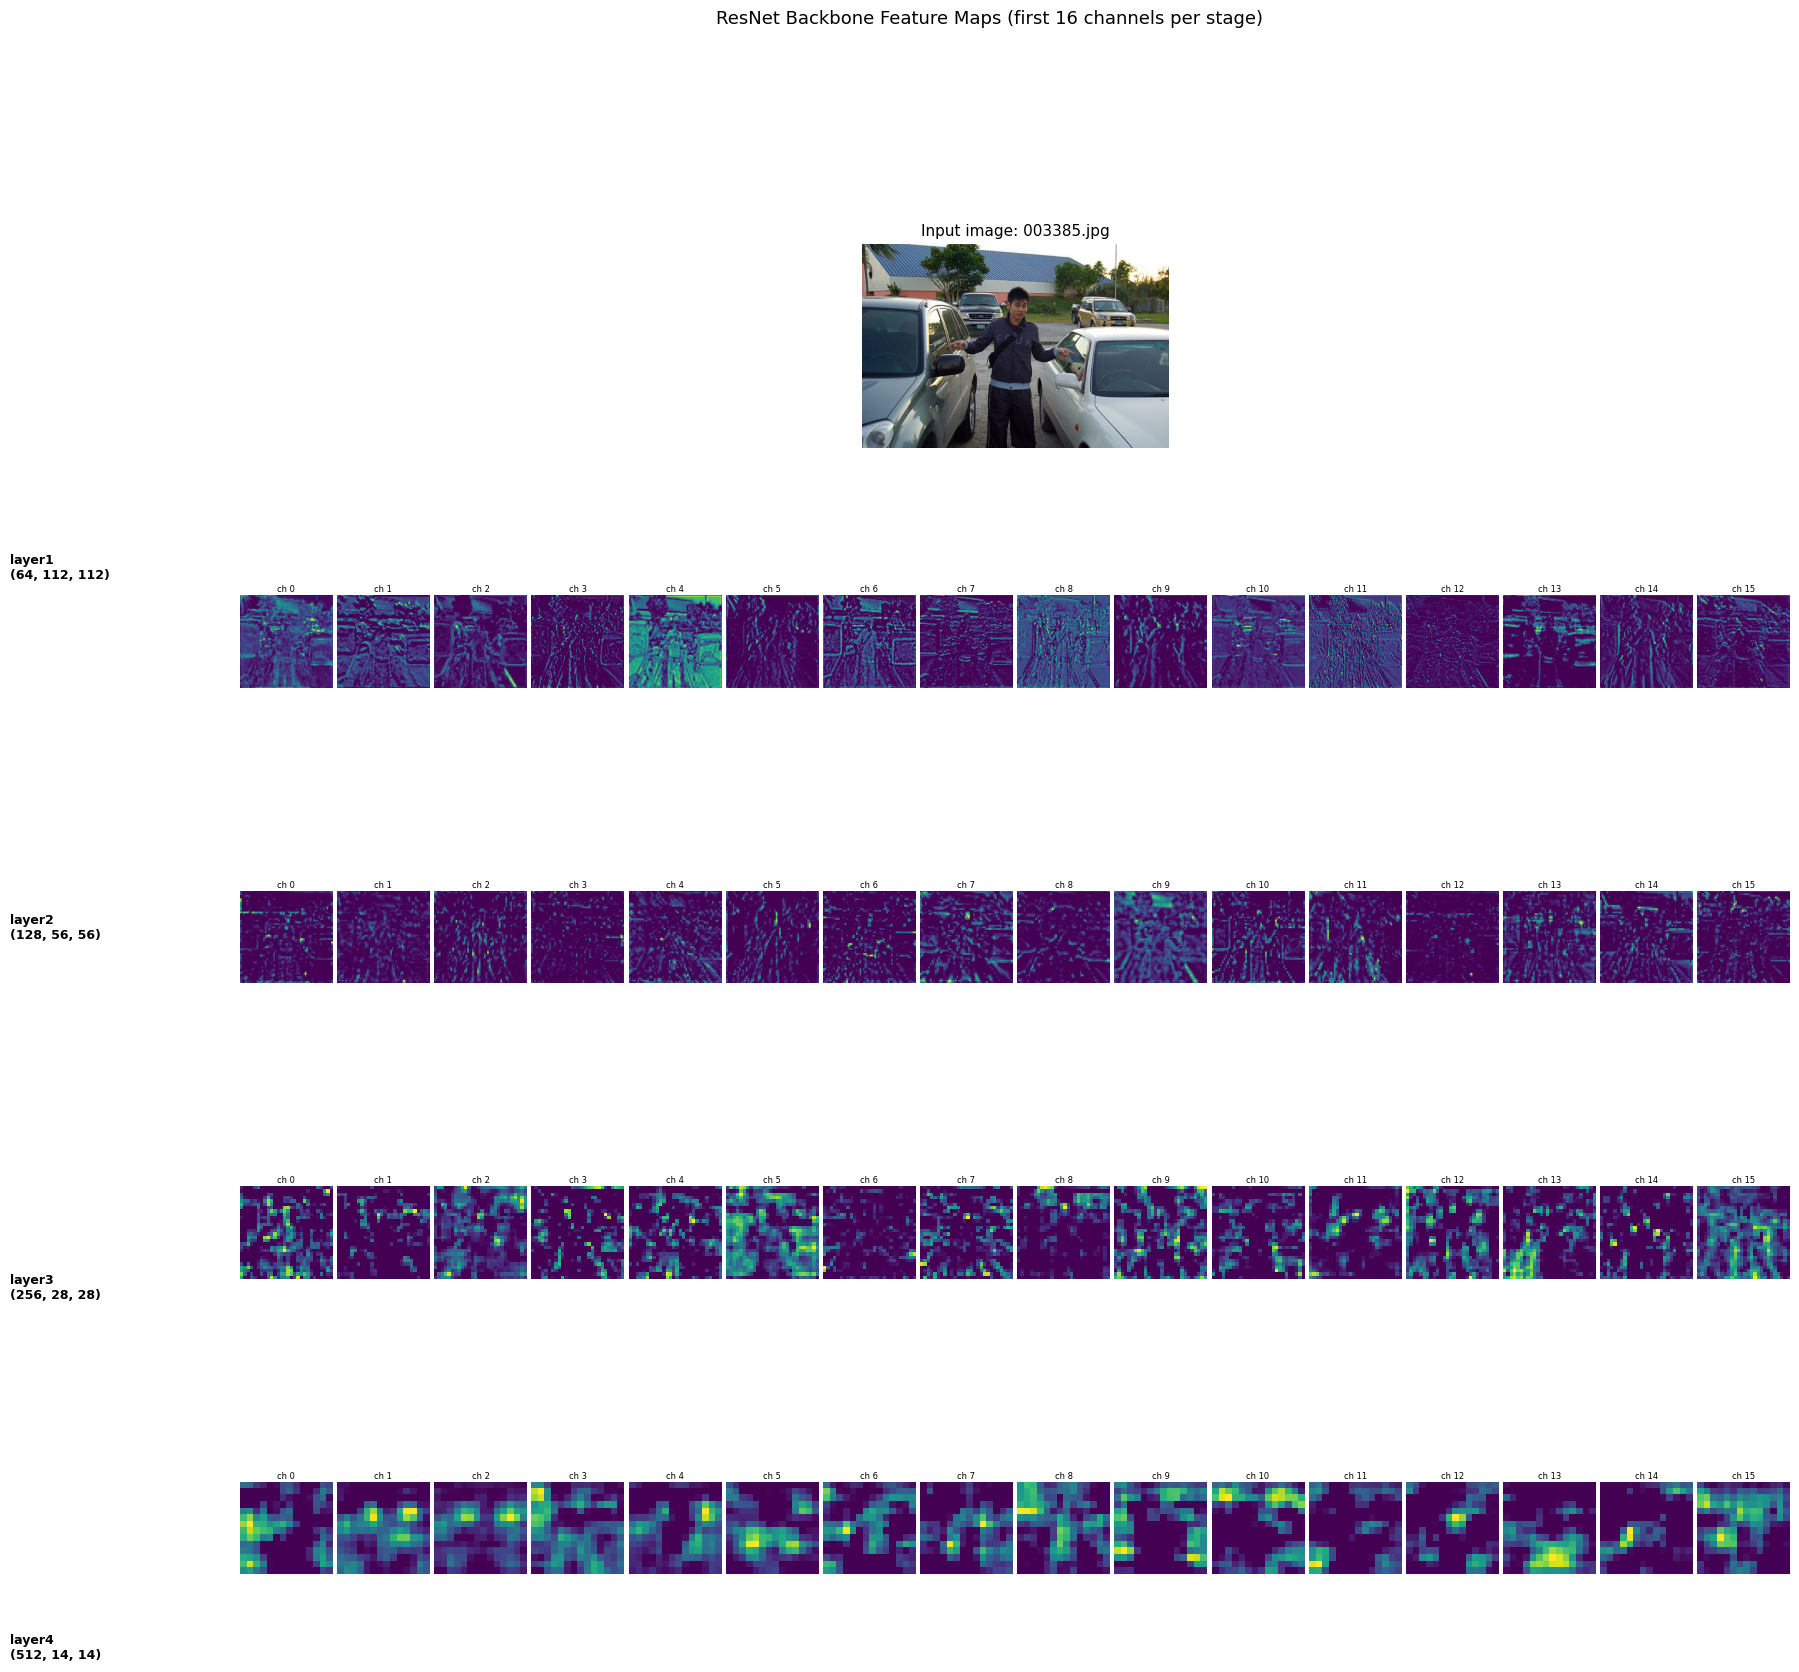

In [52]:
def show_feature_maps(captured_feats, image_rgb, n_channels=16, cmap="viridis"):
    """Show n_channels activation maps for each captured stage."""
    stages = list(captured_feats.keys())
    n_stages = len(stages)

    fig = plt.figure(figsize=(20, 4 * n_stages + 2))
    outer = gridspec.GridSpec(n_stages + 1, 1, figure=fig, hspace=0.45)

    # original image at top
    ax_img = fig.add_subplot(outer[0])
    ax_img.imshow(image_rgb)
    ax_img.set_title(f"Input image: {image_name}", fontsize=11)
    ax_img.axis("off")

    for row_idx, stage in enumerate(stages):
        feat = captured_feats[stage][0]          # [C, H, W]
        n_cols = n_channels
        inner = gridspec.GridSpecFromSubplotSpec(
            1, n_cols, subplot_spec=outer[row_idx + 1], wspace=0.05
        )
        for ch in range(min(n_cols, feat.shape[0])):
            ax = fig.add_subplot(inner[ch])
            fmap = feat[ch].numpy()
            fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
            ax.imshow(fmap, cmap=cmap, vmin=0, vmax=1)
            ax.set_title(f"ch {ch}", fontsize=6, pad=2)
            ax.axis("off")

        # stage label on the left
        fig.text(
            0.01,
            (n_stages - row_idx - 0.5) / (n_stages + 1),
            f"{stage}\n{tuple(captured_feats[stage].shape[1:])}",
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold",
            rotation=0,
        )

    plt.suptitle("ResNet Backbone Feature Maps (first 16 channels per stage)", fontsize=13, y=1.01)
    plt.show()


show_feature_maps(captured, image_rgb, n_channels=16)